# Mapping

Thomas E. Saunders

## Set up

In [ ]:
#| message: false

library(akldogs)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Linking to GEOS 3.13.1, GDAL 3.11.4, PROJ 9.7.0; sf_use_s2() is TRUE


Attaching package: 'scales'

The following object is masked from 'package:purrr':

    discard

The following object is masked from 'package:readr':

    col_factor

Read in regional data created in Data Analysis notebook

In [ ]:
#| message: false

regional_files <- list.files(path = "../outputs", 
                           pattern = "regions|breed", 
                           full.names = TRUE)

regional_data <- 
  regional_files |> 
  map(read_csv) |> 
  set_names(path_file(str_extract(regional_files, "[^-]+(?=\\.[^.]+$)")) |>
              path_ext_remove())

Rows: 2284 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): breed_reg, breed_imp
dbl (1): animal_id
lgl (1): is_match

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 105 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): category, group
dbl (4): observed, expected, residual, percent_diff

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 182 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): suburb, local_board, region
dbl (9): attacks_suburb, attacks_board, attacks_region, known_suburb, known_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ S

Get Auckland human population by Local Board

In [ ]:
#| message: false

# Source: https://figure.nz/chart/bSr6yQmn9V9BFrXK

auck_pop <- 
  read_csv("../data/2023-auckland-population.csv") |> 
  filter(`Census year` == "2023" & `Local board area` != "Auckland") |> 
  mutate(
    local_board = paste0(`Local board area`, " Local Board Area"),
    local_board = case_when(
      local_board == "Auckland Local Board Area" ~ "Total Auckland",
      .default = local_board)
  ) |> 
  rename(census_year = `Census year`,
         population = Value) |> 
  select(census_year, local_board, population)

Rows: 154 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Census year, Local board area, Local board area Code, Measure, Valu...
dbl (1): Value
lgl (1): Null Reason

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Import NZ map shapefile with local board divisions

In [ ]:
#| message: false

# Source: https://datafinder.stats.govt.nz/layer/120947-territorial-authority-local-board-2025-clipped/

shape_nz <- st_read("../data/shapefiles/nz/territorial-authority-local-board-2025-clipped.shp") |> 
  rename(local_board = TALB2025_1) |> 
  select(local_board, geometry) |> 
  filter(local_board != c("Area Outside Territorial Authority", "Chatham Islands Territory"))

Reading layer `territorial-authority-local-board-2025-clipped' from data source 
  `C:\Users\Tom\Projects\dog-control\data\shapefiles\nz\territorial-authority-local-board-2025-clipped.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 88 features and 6 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 1089970 ymin: 4747987 xmax: 2470102 ymax: 6223156
Projected CRS: NZGD2000 / New Zealand Transverse Mercator 2000

Join locality data to shapefile data

In [ ]:
auckland <-
  shape_nz |>
  st_simplify(dTolerance = 100) |> 
  mutate(
    include = case_when(local_board %in% auck_pop$local_board ~ TRUE,
                        local_board %in% c("Kaipara District", 
                                           "Thames-Coromandel District",
                                           "Waikato District",
                                           "Hauraki District",
                                           "Whangarei District") ~ TRUE)
  ) |>
  left_join(akldogs::locality |> 
              select(local_board, region) |>
              unique(),
            by = join_by(local_board)) |>
  mutate(
    region = case_when(local_board == "Aotea/Great Barrier Local Board Area" ~ "north",
                       .default = region),
    label = cumsum(!is.na(region))
  ) |> 
  filter(include == TRUE)

auckland$region <- as.factor(auckland$region)

## Maps

Map of NZ with border around Auckland

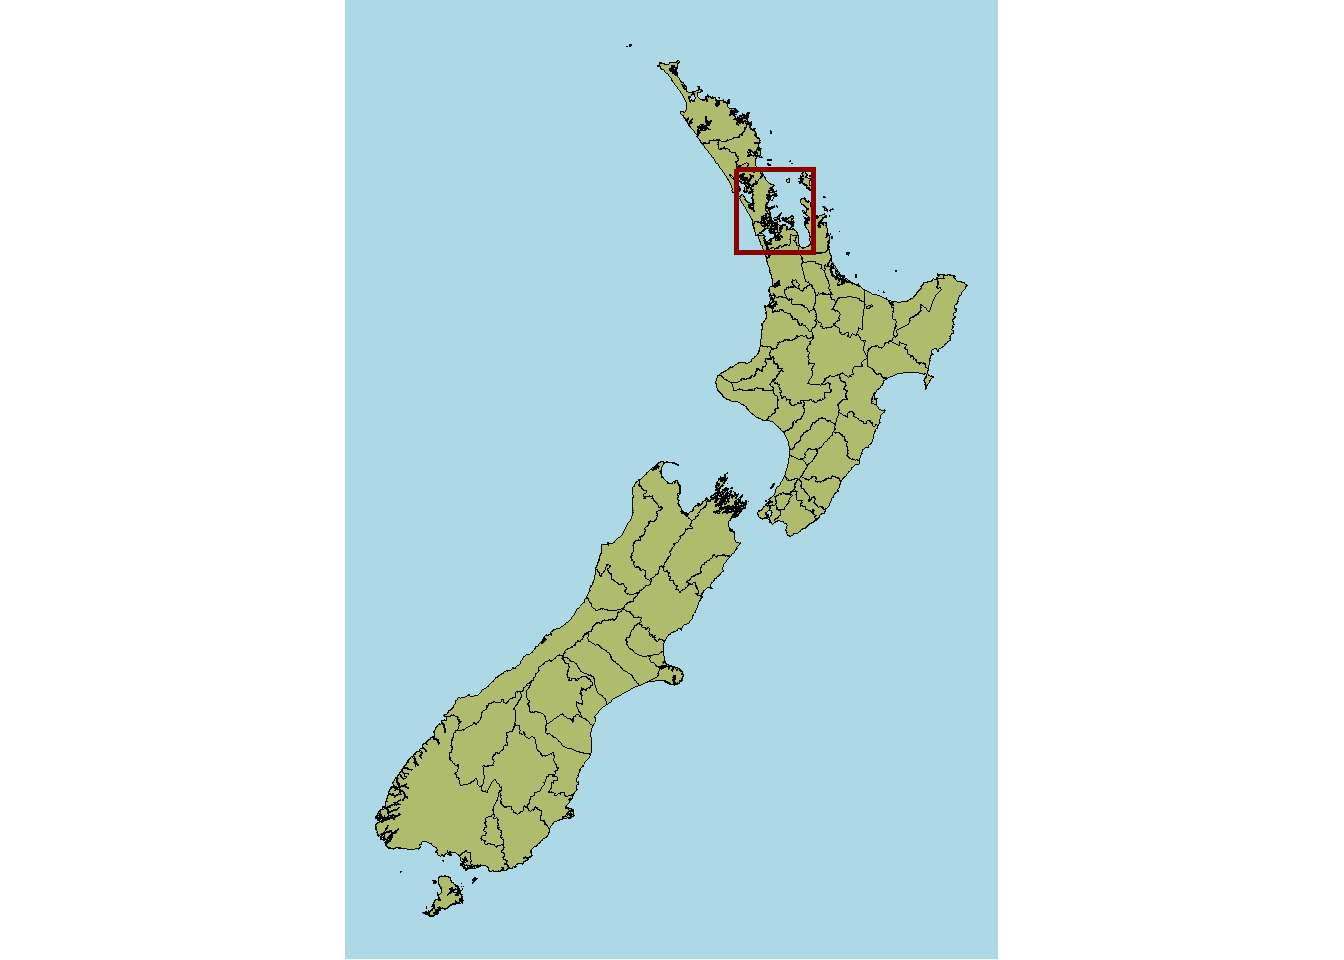

In [ ]:
map_nz <- shape_nz |> 
  st_simplify(dTolerance = 100) |>
  ggplot() +
  geom_sf(fill = "#b0bc6d", colour = "black") +
  geom_rect(
    xmin = 1700000,
    ymin = 5869755,
    xmax = 1830000,
    ymax = 6010000,
    fill = NA, 
    colour = "darkred",
    linewidth = 1
  ) +
  theme_void() +
  theme(legend.position = "none",
        panel.background = element_rect(fill = "lightblue"))

map_nz

Auckland regions

In [ ]:
map_regions <- ggplot() +
  geom_sf(data = auckland, colour = NA) +
  geom_sf(data = auckland |> 
            filter(!is.na(region)), aes(fill = region), colour = NA) + 
  scale_fill_manual(values = region_colours) +
  coord_sf(
    xlim = c(1700000, 1830000),
    ylim = c(5869755, 6010000),
    expand = FALSE
  ) +
  theme_void() +
  theme(legend.position = "none")

Auckland Local Boards

In [ ]:
map_boards <- ggplot() +
  geom_sf(data = auckland, aes(fill = local_board), colour = NA) + 
  scale_fill_manual(values = board_colours) +
  coord_sf(
    xlim = c(1700000, 1830000),
    ylim = c(5869755, 6010000),
    expand = FALSE
  ) +
  theme_void() +
  theme(legend.position = "none")

Join maps together

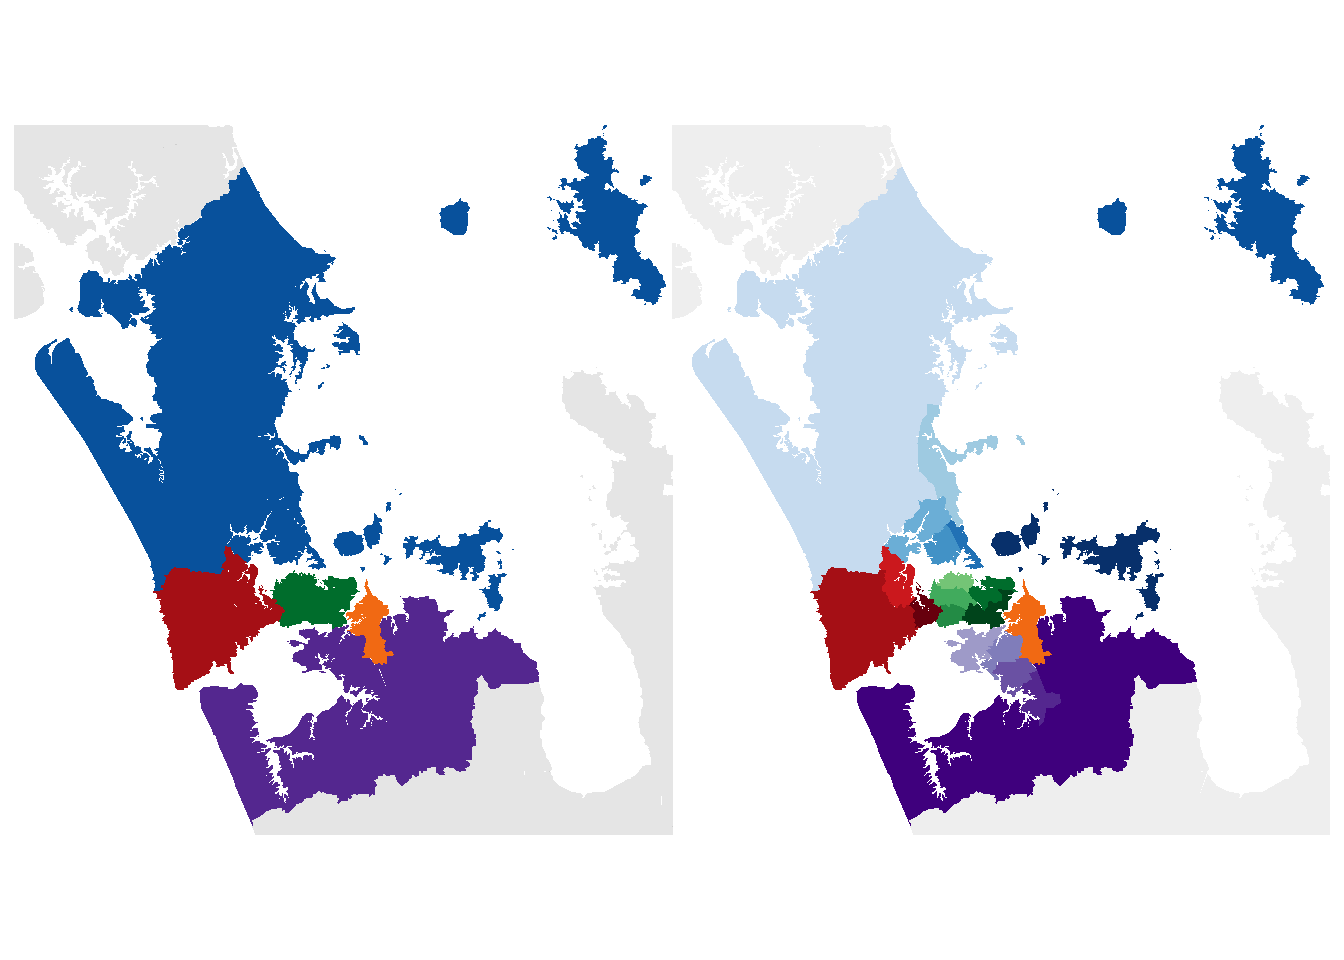

In [ ]:
#| label: fig-regions-boards
#| fig-cap: "Left: Auckland regions (North = blue, West = red, Central = green, East = orange, South = purple). Right: Auckland's 21 Local Boards, coloured based on their parent region."

map_regions + map_boards

Proportion of desexed dogs by Local Board

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.

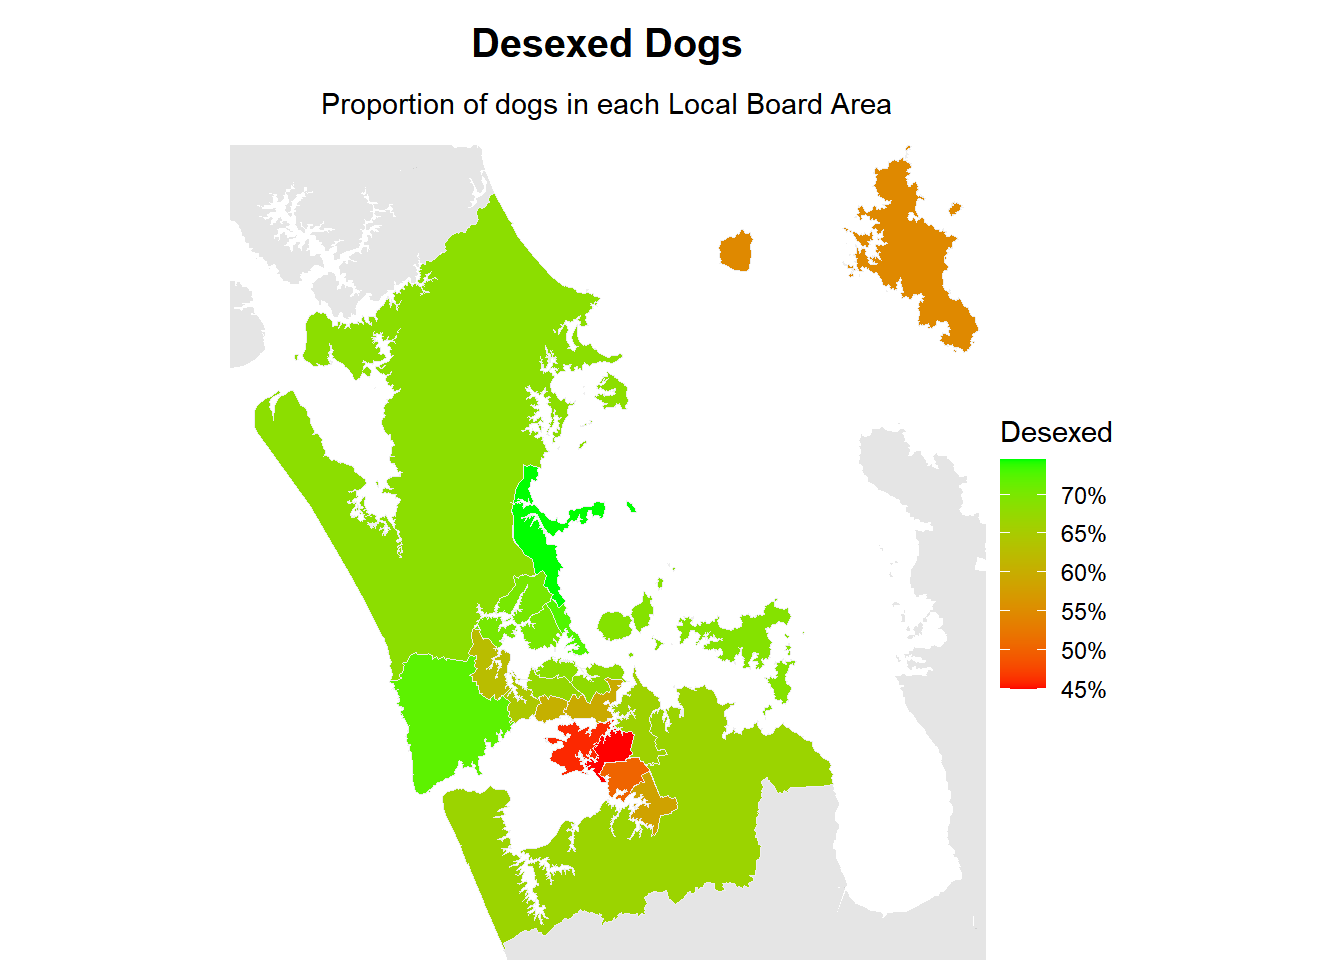

In [ ]:
#| label: map-desex

map_desex <-
  auckland |> 
  left_join(regional_data$regions_reg |> filter(metric == "animal_desexed"), 
            by = join_by(local_board)) |> 
  select(local_board, p_board, geometry) |> 
  unique() |> 
  filter(!is.na(p_board))

plot_local_board(auckland, 
                 map_desex,
                 p_board,
                 "Desexed Dogs",
                 "Proportion of dogs in each Local Board Area") +
  scale_fill_gradient(low = "red",
                      high = "green",
                      name = "Desexed",
                      labels = label_percent())

Proportion of dogs with a classification under the Dog Control Act by Local Board

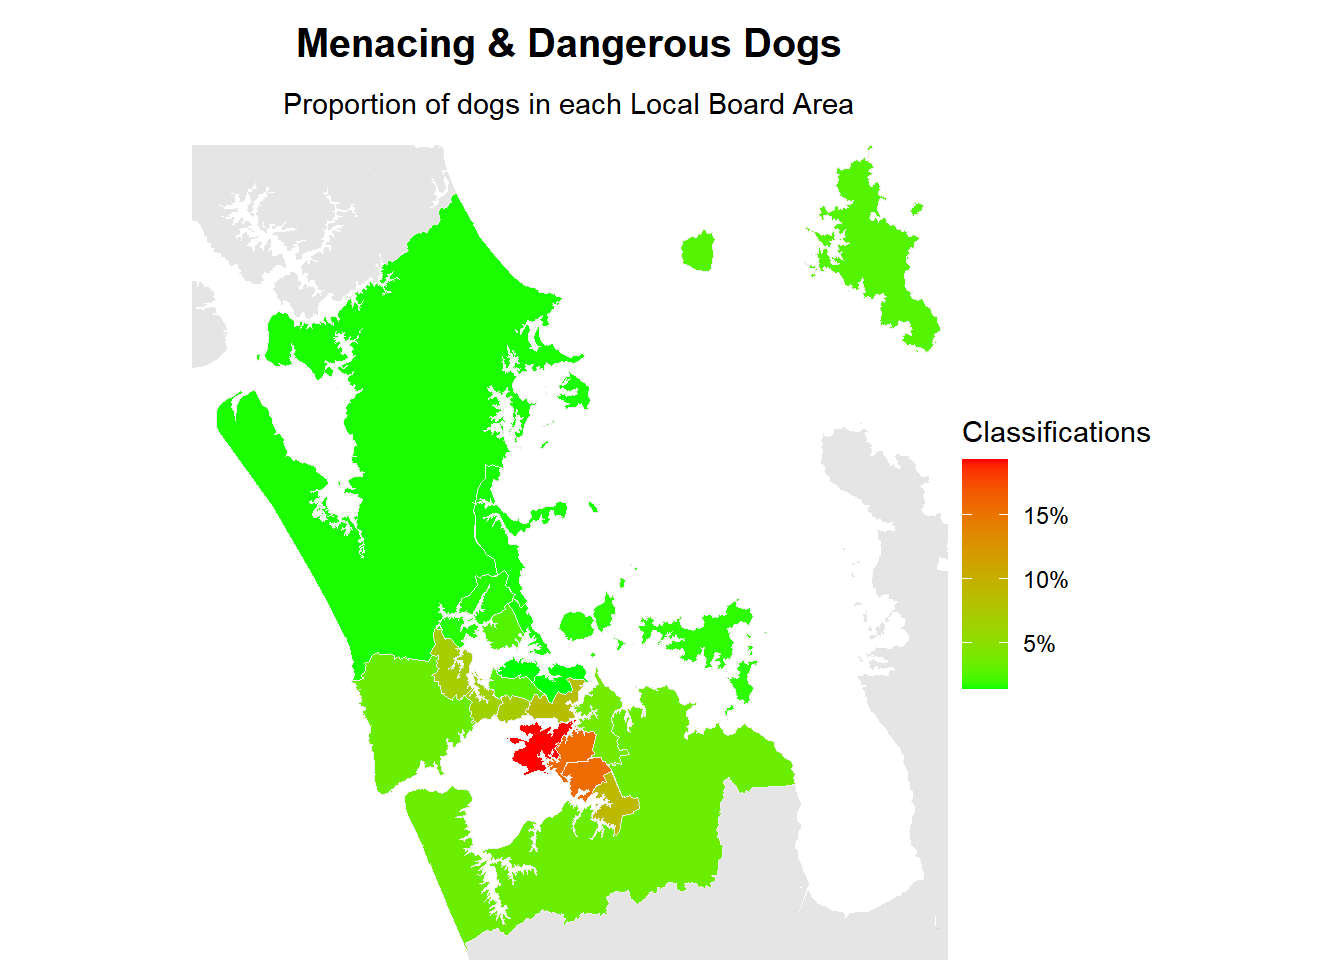

In [ ]:
#| label: map-class

map_class <-
  auckland |> 
  left_join(regional_data$regions_reg |> filter(metric == "classification"), 
            by = join_by(local_board)) |> 
  select(local_board, p_board, geometry) |> 
  unique() |> 
  filter(!is.na(p_board))

plot_local_board(auckland, 
                 map_class,
                 p_board,
                 "Menacing & Dangerous Dogs",
                 "Proportion of dogs in each Local Board Area",
                 "Classifications",
                 label_percent())

Rate of dog attacks by Local Board

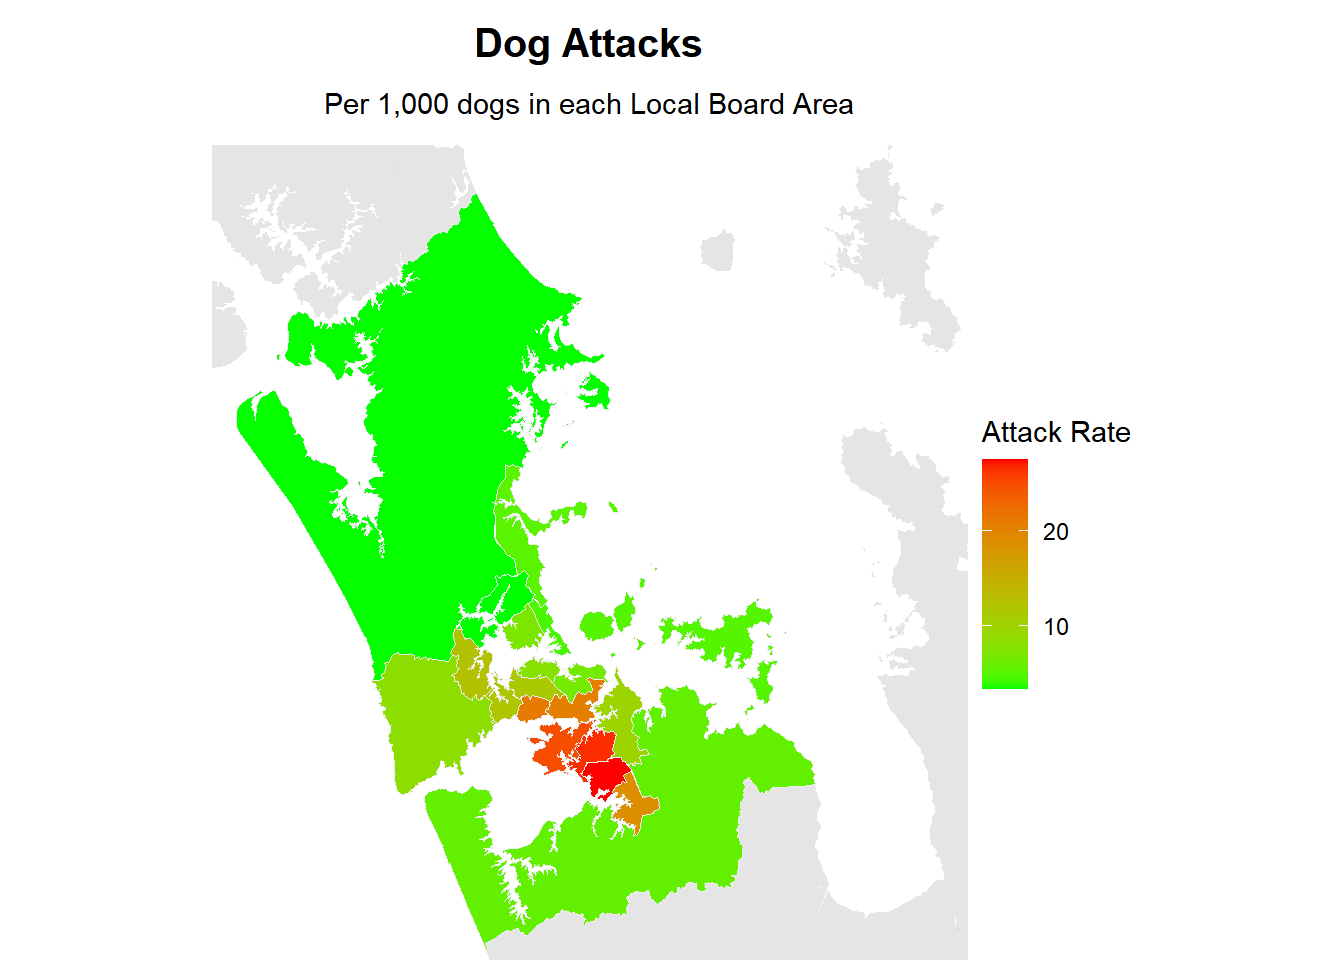

In [ ]:
#| label: map-attacks

map_attacks <-
  auckland |> 
  left_join(regional_data$regions_attacks |> 
              select(local_board, rate_board) |> 
              unique(),
            by = join_by(local_board)) |> 
  select(local_board, rate_board, geometry) |> 
  filter(!is.na(rate_board))

plot_local_board(auckland, 
                 map_attacks,
                 rate_board,
                 "Dog Attacks",
                 "Per 1,000 dogs in each Local Board Area",
                 "Attack Rate")

Rate of dog impounds by Local Board

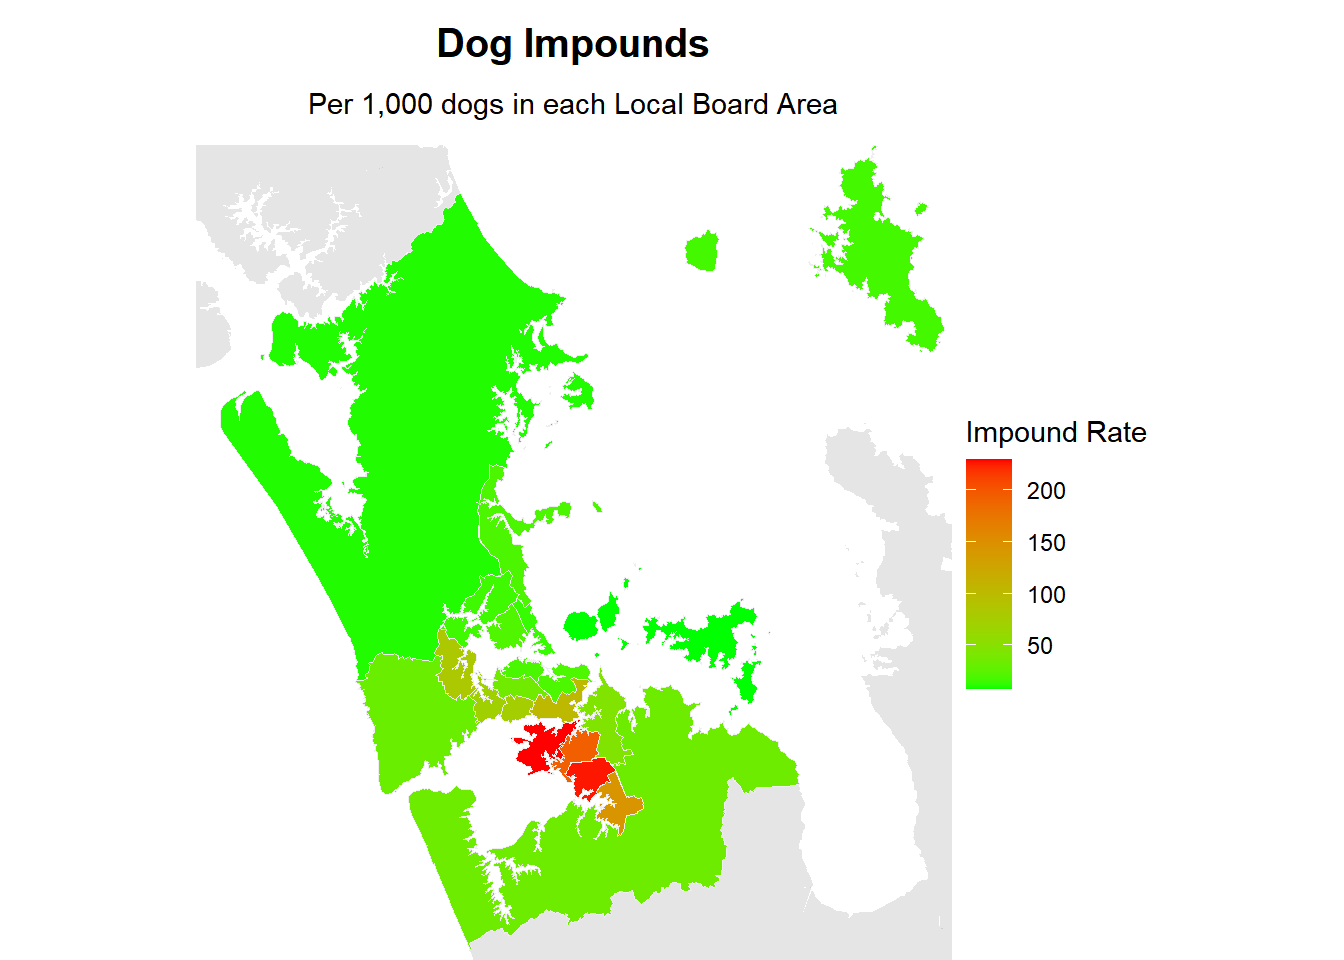

In [ ]:
#| label: map-impounds

map_impounds <-
  auckland |> 
  left_join(regional_data$regions_impounds, by = join_by(local_board)) |> 
  select(local_board, rate_board, geometry) |> 
  unique() |> 
  filter(!is.na(rate_board))

plot_local_board(auckland, 
                 map_impounds,
                 rate_board,
                 "Dog Impounds",
                 "Per 1,000 dogs in each Local Board Area",
                 "Impound Rate")

Rate of dog impounds due to attacks on people by Local Board

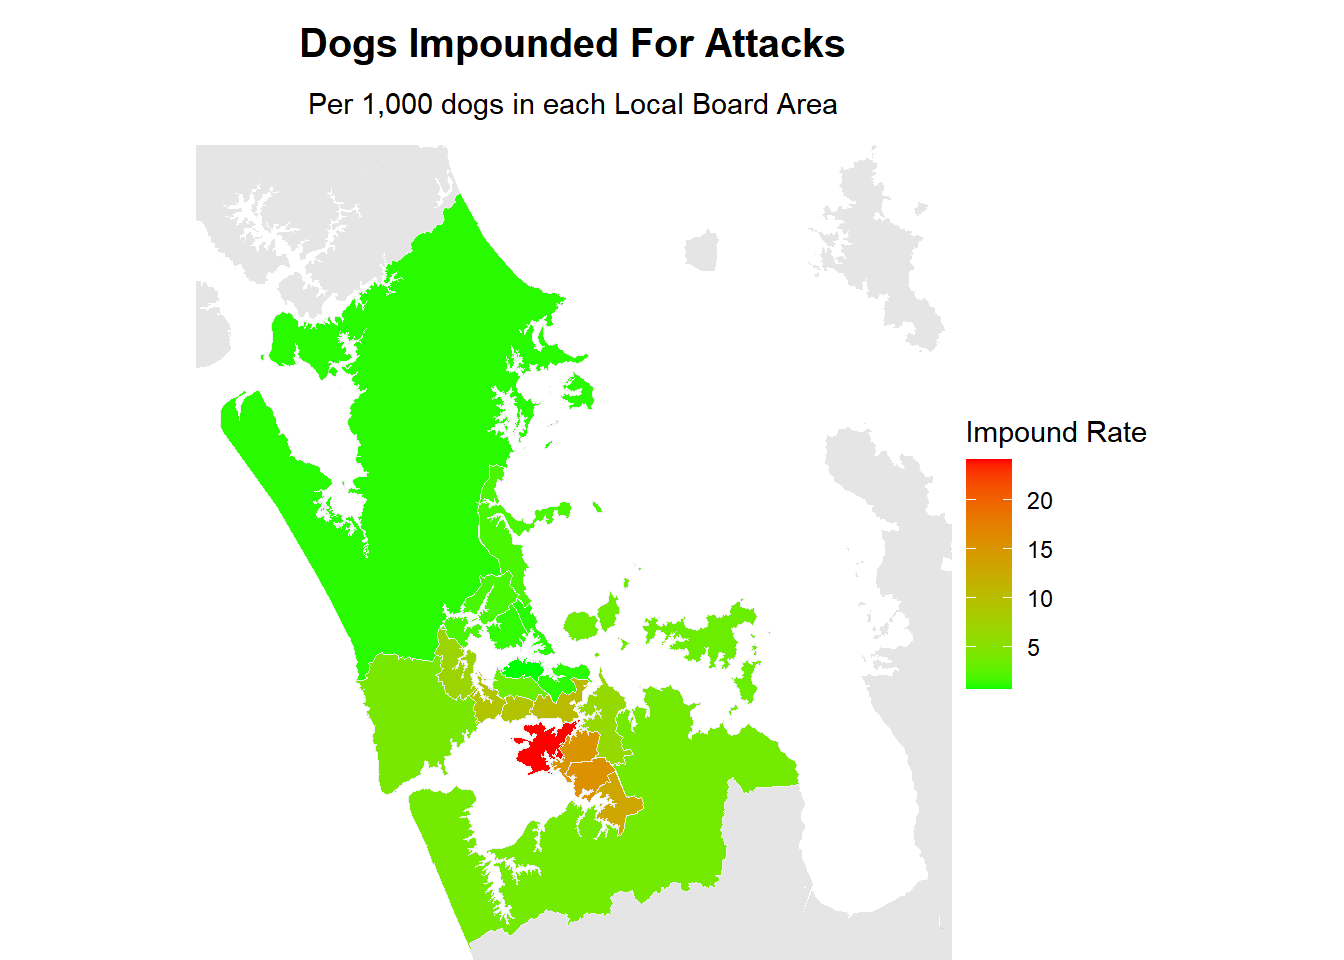

In [ ]:
map_impounds_attacks <-
  auckland |> 
  left_join(regional_data$regions_impounds_attacks, by = join_by(local_board)) |> 
  select(local_board, rate_attack_board, geometry) |> 
  unique() |> 
  filter(!is.na(rate_attack_board))

plot_local_board(auckland, 
                 map_impounds_attacks,
                 rate_attack_board,
                 "Dogs Impounded For Attacks",
                 "Per 1,000 dogs in each Local Board Area",
                 "Impound Rate")

Proportion of impounded dogs euthanised by Local Board

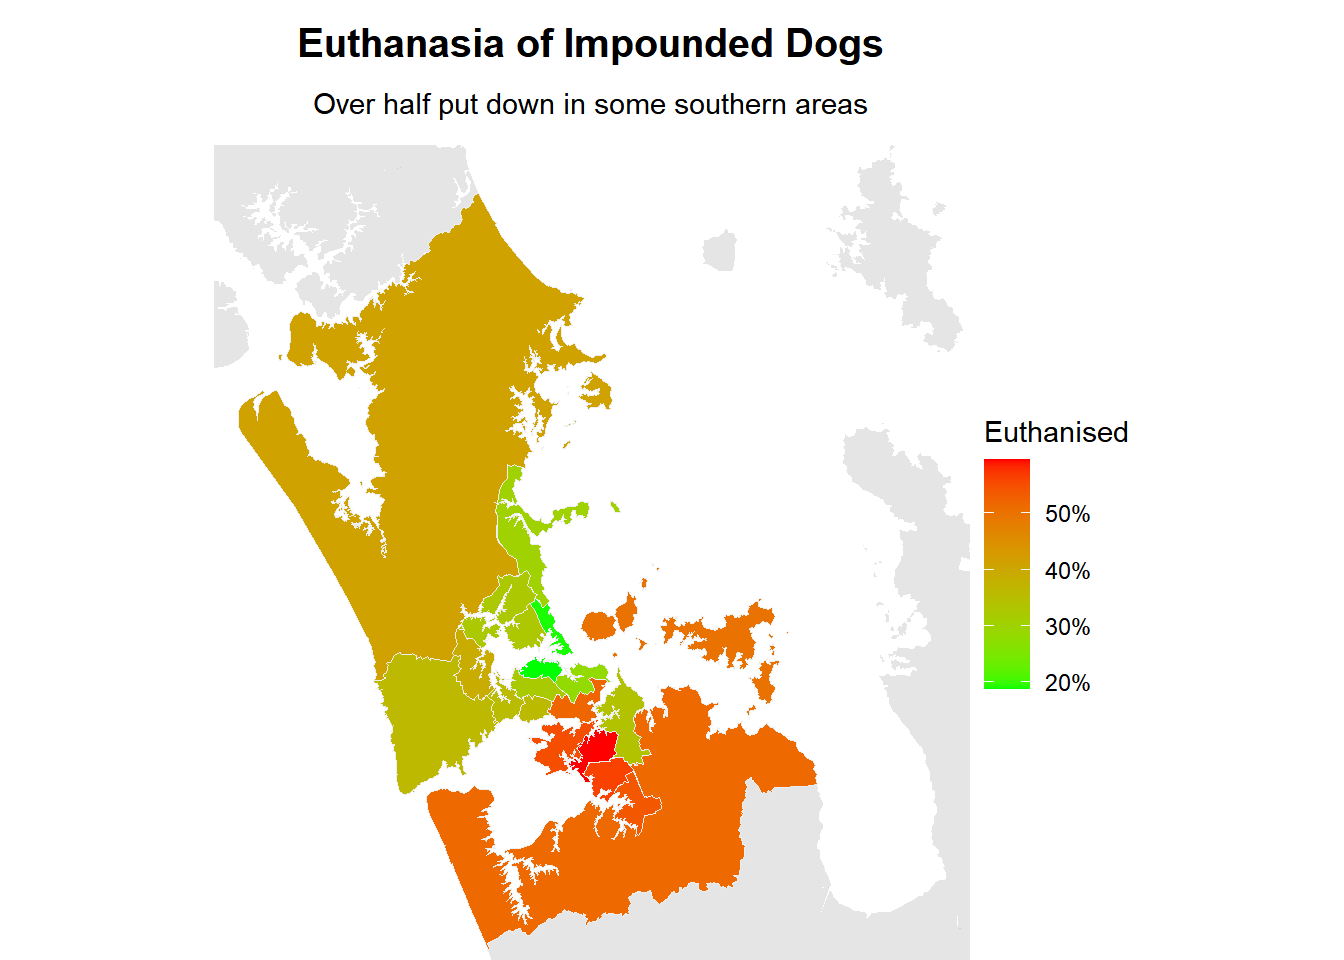

In [ ]:
#| label: map-euth

map_impounds_euthanised <-
  auckland |> 
  left_join(regional_data$regions_impounds_outcome, by = join_by(local_board)) |> 
  select(local_board, status, proportion, geometry) |> 
  unique() |> 
  filter(status == "Euthanised" & local_board != "Aotea/Great Barrier Local Board Area")

plot_local_board(auckland, 
                 map_impounds_euthanised,
                 proportion,
                 "Euthanasia of Impounded Dogs",
                 "Over half put down in some southern areas",
                 "Euthanised",
                 label_percent())